## Imports

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import groupby

sys.path.append("../src")

from pattern_mining import (
    load_student_sequences,
    split_by_group,
    mine_patterns,
    build_pattern_table,
)

sns.set_style("whitegrid")
pd.set_option("display.max_colwidth", 80)

## Load & Split

In [2]:
processed_path = "../data/processed/"

student_sequences = load_student_sequences(processed_path)
print("Shape:", student_sequences.shape)
print("Columns:", student_sequences.columns.tolist())
print()
print(student_sequences["performance_group"].value_counts())

Shape: (20788, 4)
Columns: ['id_student', 'sequence', 'performance_label', 'performance_group']

performance_group
High    14323
Low      6465
Name: count, dtype: int64


In [3]:
high_sequences, low_sequences = split_by_group(student_sequences)

n_high = len(high_sequences)
n_low  = len(low_sequences)

print(f"High sequences: {n_high:,}")
print(f"Low  sequences: {n_low:,}")
print()
print("Sample High sequence (first 10 items):")
print(high_sequences[0][:10])
print()
print("Sample Low sequence (first 10 items):")
print(low_sequences[0][:10])

High sequences: 14,323
Low  sequences: 6,465

Sample High sequence (first 10 items):
['StudyMaterial', 'StudyMaterial', 'StudyMaterial', 'StudyMaterial', 'StudyMaterial', 'Navigation', 'StudyMaterial', 'Discussion', 'Discussion', 'StudyMaterial']

Sample Low sequence (first 10 items):
['Navigation', 'Discussion', 'Discussion', 'Discussion', 'Navigation', 'Discussion', 'Navigation', 'Discussion', 'StudyMaterial', 'StudyMaterial']


## Compress & Truncate Sequences

Raw sequences are hundreds of items long — PrefixSpan would run forever.
We compress consecutive repeats and cap at 20 items per student.

In [4]:
def compress_and_truncate(seq, max_len=20):
    """Remove consecutive duplicates, then cap length."""
    compressed = [k for k, _ in groupby(seq)]
    return compressed[:max_len]

high_sequences_trunc = [compress_and_truncate(seq) for seq in high_sequences]
low_sequences_trunc  = [compress_and_truncate(seq) for seq in low_sequences]

print("After compression + truncation:")
print(f"  Avg High length: {np.mean([len(s) for s in high_sequences_trunc]):.1f}")
print(f"  Avg Low  length: {np.mean([len(s) for s in low_sequences_trunc]):.1f}")
print()
print("Sample High (truncated):", high_sequences_trunc[0])
print("Sample Low  (truncated):", low_sequences_trunc[0])

After compression + truncation:
  Avg High length: 20.0
  Avg Low  length: 18.1

Sample High (truncated): ['StudyMaterial', 'Navigation', 'StudyMaterial', 'Discussion', 'StudyMaterial', 'Navigation', 'StudyMaterial', 'Discussion', 'StudyMaterial', 'Discussion', 'StudyMaterial', 'Navigation', 'StudyMaterial', 'Navigation', 'StudyMaterial', 'External', 'Discussion', 'Navigation', 'Discussion', 'Navigation']
Sample Low  (truncated): ['Navigation', 'Discussion', 'Navigation', 'Discussion', 'Navigation', 'Discussion', 'StudyMaterial', 'Discussion', 'Navigation', 'Discussion', 'Navigation', 'Discussion', 'Navigation', 'Discussion', 'Navigation', 'Quiz', 'Navigation', 'Quiz', 'Navigation', 'Discussion']


## Mine Patterns

In [5]:
MIN_SUPPORT_PCT = 0.30
MAX_LENGTH      = 4

min_sup_high = int(MIN_SUPPORT_PCT * n_high)
min_sup_low  = int(MIN_SUPPORT_PCT * n_low)

print(f"min_support High: {min_sup_high:,}  ({MIN_SUPPORT_PCT*100:.0f}% of {n_high:,})")
print(f"min_support Low:  {min_sup_low:,}  ({MIN_SUPPORT_PCT*100:.0f}% of {n_low:,})")

min_support High: 4,296  (30% of 14,323)
min_support Low:  1,939  (30% of 6,465)


In [6]:
print("Mining High patterns...")
patterns_high = mine_patterns(high_sequences_trunc, min_sup_high, MAX_LENGTH)
print(f"Found {len(patterns_high):,} patterns")

Mining High patterns...
Found 346 patterns


In [7]:
print("Mining Low patterns...")
patterns_low = mine_patterns(low_sequences_trunc, min_sup_low, MAX_LENGTH)
print(f"Found {len(patterns_low):,} patterns")

Mining Low patterns...
Found 321 patterns


## Build Pattern Table

In [8]:
pattern_table = build_pattern_table(patterns_high, patterns_low, n_high, n_low)

print("Shape:", pattern_table.shape)
print()
pattern_table.head(10)

Shape: (347, 6)



,pattern,support_high,support_low,support_high_pct,support_low_pct,difference
0,"External,StudyMaterial,External,Discussion",5116,0,35.72,0.0,35.72
1,"StudyMaterial,External,External,Discussion",4962,0,34.64,0.0,34.64
2,"Discussion,Navigation,Discussion,External",4939,0,34.48,0.0,34.48
3,"Discussion,Navigation,External,Navigation",4866,0,33.97,0.0,33.97
4,"External,External,StudyMaterial,Discussion",4831,0,33.73,0.0,33.73
5,"Discussion,External,Discussion,Navigation",4815,0,33.62,0.0,33.62
6,"External,Discussion,External",4808,0,33.57,0.0,33.57
7,"External,External,Navigation,Navigation",4798,0,33.50,0.0,33.50
8,"Discussion,External,Discussion,Discussion",4722,0,32.97,0.0,32.97
9,"Discussion,Navigation,External,Discussion",4719,0,32.95,0.0,32.95


In [9]:
print("Top 10 HIGH-discriminative patterns:")
print(
    pattern_table.head(10)[["pattern", "support_high_pct", "support_low_pct", "difference"]]
    .to_string(index=False)
)
print()
print("Top 10 LOW-discriminative patterns:")
print(
    pattern_table.tail(10)[["pattern", "support_high_pct", "support_low_pct", "difference"]]
    .to_string(index=False)
)

Top 10 HIGH-discriminative patterns:
                                   pattern  support_high_pct  support_low_pct  difference
External,StudyMaterial,External,Discussion             35.72              0.0       35.72
StudyMaterial,External,External,Discussion             34.64              0.0       34.64
 Discussion,Navigation,Discussion,External             34.48              0.0       34.48
 Discussion,Navigation,External,Navigation             33.97              0.0       33.97
External,External,StudyMaterial,Discussion             33.73              0.0       33.73
 Discussion,External,Discussion,Navigation             33.62              0.0       33.62
              External,Discussion,External             33.57              0.0       33.57
   External,External,Navigation,Navigation             33.50              0.0       33.50
 Discussion,External,Discussion,Discussion             32.97              0.0       32.97
 Discussion,Navigation,External,Discussion             32.95   

## Visualise Top Discriminative Patterns

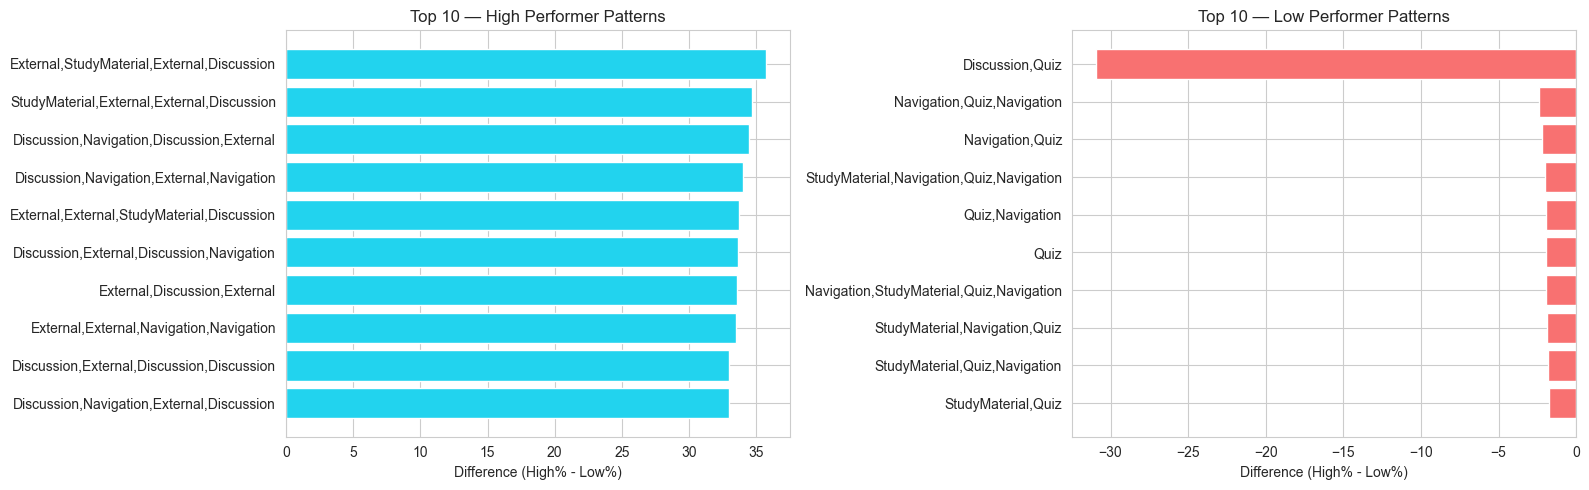

Saved to results/figures/top_discriminative_patterns.png


In [10]:
top_high = pattern_table.head(10).copy()
top_low  = pattern_table.tail(10).copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(top_high["pattern"][::-1], top_high["difference"][::-1], color="#22d3ee")
axes[0].set_title("Top 10 — High Performer Patterns")
axes[0].set_xlabel("Difference (High% - Low%)")

axes[1].barh(top_low["pattern"], top_low["difference"], color="#f87171")
axes[1].set_title("Top 10 — Low Performer Patterns")
axes[1].set_xlabel("Difference (High% - Low%)")

plt.tight_layout()
plt.savefig("../results/figures/top_discriminative_patterns.png", dpi=150)
plt.show()
print("Saved to results/figures/top_discriminative_patterns.png")

## Save patterns.csv

In [11]:
output_path = "../results/patterns.csv"
pattern_table.to_csv(output_path, index=False)
print(f"Saved {len(pattern_table):,} patterns to {output_path}")
print(f"Columns: {pattern_table.columns.tolist()}")

Saved 347 patterns to ../results/patterns.csv
Columns: ['pattern', 'support_high', 'support_low', 'support_high_pct', 'support_low_pct', 'difference']


## Verify

In [12]:
verify = pd.read_csv("../results/patterns.csv")
print("Shape:", verify.shape)
print("Columns:", verify.columns.tolist())
print()
verify.head(5)

Shape: (347, 6)
Columns: ['pattern', 'support_high', 'support_low', 'support_high_pct', 'support_low_pct', 'difference']



,pattern,support_high,support_low,support_high_pct,support_low_pct,difference
0,"External,StudyMaterial,External,Discussion",5116,0,35.72,0.0,35.72
1,"StudyMaterial,External,External,Discussion",4962,0,34.64,0.0,34.64
2,"Discussion,Navigation,Discussion,External",4939,0,34.48,0.0,34.48
3,"Discussion,Navigation,External,Navigation",4866,0,33.97,0.0,33.97
4,"External,External,StudyMaterial,Discussion",4831,0,33.73,0.0,33.73
